# Install Packages

In [ ]:
import os
import random
import shutil
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from tqdm import tqdm

# DEVICE

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Connect Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# DATASET PATH

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Data_Set/Deep_Learning/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"

# PATIENT-WISE SPLIT

In [ ]:
data = []

for cls in ["benign", "malignant"]:
    class_path = os.path.join(DATASET_PATH, cls)

    for root, _, files in os.walk(class_path):
        for file in files:
            if file.endswith(".png"):

                full_path = os.path.join(root, file)

                patient_id = file.split("-")[2]

                data.append([full_path, cls, patient_id])

df = pd.DataFrame(data, columns=["path", "label", "patient_id"])

# SPLIT PATIENTS

In [ ]:
patients = df.groupby("patient_id")["label"].first().reset_index()

benign = patients[patients["label"]=="benign"]["patient_id"].tolist()
malignant = patients[patients["label"]=="malignant"]["patient_id"].tolist()

def split(lst, tr=0.7, va=0.15):
    random.seed(42)
    random.shuffle(lst)
    n = len(lst)

    t = int(n*tr)
    v = int(n*(tr+va))

    return lst[:t], lst[t:v], lst[v:]


ben_tr, ben_va, ben_te = split(benign)
mal_tr, mal_va, mal_te = split(malignant)

# BUILD DATAFRAMES

In [ ]:
def filter_patients(p_list):
    return df[df["patient_id"].isin(p_list)]

train_df = pd.concat([filter_patients(ben_tr), filter_patients(mal_tr)])
val_df   = pd.concat([filter_patients(ben_va), filter_patients(mal_va)])
test_df  = pd.concat([filter_patients(ben_te), filter_patients(mal_te)])

# CREATE FOLDER STRUCTURE

In [ ]:
OUT_DIR = "/content/drive/MyDrive/Data_Set/Deep_Learning/breakhis_split"

for split in ["train","val","test"]:
    for cls in ["benign","malignant"]:
        os.makedirs(os.path.join(OUT_DIR, split, cls), exist_ok=True)

# COPY IMAGES

In [ ]:
def copy(df, split):
    for _, r in df.iterrows():
        dst = os.path.join(OUT_DIR, split, r["label"], os.path.basename(r["path"]))
        shutil.copy2(r["path"], dst)

copy(train_df, "train")
copy(val_df, "val")
copy(test_df, "test")

# TRANSFORMS

In [ ]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# DATASETS & LOADERS

In [ ]:
train_dataset = ImageFolder(OUT_DIR+"/train", transform=train_transform)
val_dataset   = ImageFolder(OUT_DIR+"/val", transform=test_transform)
test_dataset  = ImageFolder(OUT_DIR+"/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# DenseNet121

In [ ]:
from torchvision import models

model = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

model.classifier = nn.Linear(
    model.classifier.in_features,
    2
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 160MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

Training Function

This version stores:

Train Loss
Validation Loss
Train Accuracy
Validation Accuracy

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [ ]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm

train_losses = []
val_losses = []

train_accs = []
val_accs = []

def train_model(model):

    best_acc = 0

    for epoch in range(EPOCHS):


        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0

        train_true = []
        train_pred = []

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(1)

            train_true.extend(labels.cpu().numpy())
            train_pred.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader)

        train_acc = accuracy_score(
            train_true,
            train_pred
        )


        # ---------------- VALIDATION ----------------
        model.eval()

        val_running_loss = 0

        val_true = []
        val_pred = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                preds = outputs.argmax(1)

                val_true.extend(labels.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)

        val_acc = accuracy_score(
            val_true,
            val_pred
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss={train_loss:.4f} "
            f"Train Acc={train_acc:.4f} "
            f"Val Loss={val_loss:.4f} "
            f"Val Acc={val_acc:.4f}"
        )

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_densenet121.pth"
            )

    print("Best Validation Accuracy:", best_acc)

In [ ]:
train_model(model)

100%|██████████| 172/172 [02:14<00:00,  1.28it/s]


Epoch [1/10] Train Loss=0.1901 Train Acc=0.9192 Val Loss=0.4436 Val Acc=0.8266


100%|██████████| 172/172 [02:14<00:00,  1.28it/s]


Epoch [2/10] Train Loss=0.0744 Train Acc=0.9715 Val Loss=0.3808 Val Acc=0.8532


100%|██████████| 172/172 [02:14<00:00,  1.28it/s]


...

Epoch [8/10] Train Loss=0.0242 Train Acc=0.9916 Val Loss=0.4134 Val Acc=0.8573


100%|██████████| 172/172 [02:15<00:00,  1.27it/s]


Epoch [9/10] Train Loss=0.0193 Train Acc=0.9932 Val Loss=0.3787 Val Acc=0.8782


100%|██████████| 172/172 [02:14<00:00,  1.28it/s]


Epoch [10/10] Train Loss=0.0113 Train Acc=0.9971 Val Loss=0.2884 Val Acc=0.9073
Best Validation Accuracy: 0.907258064516129


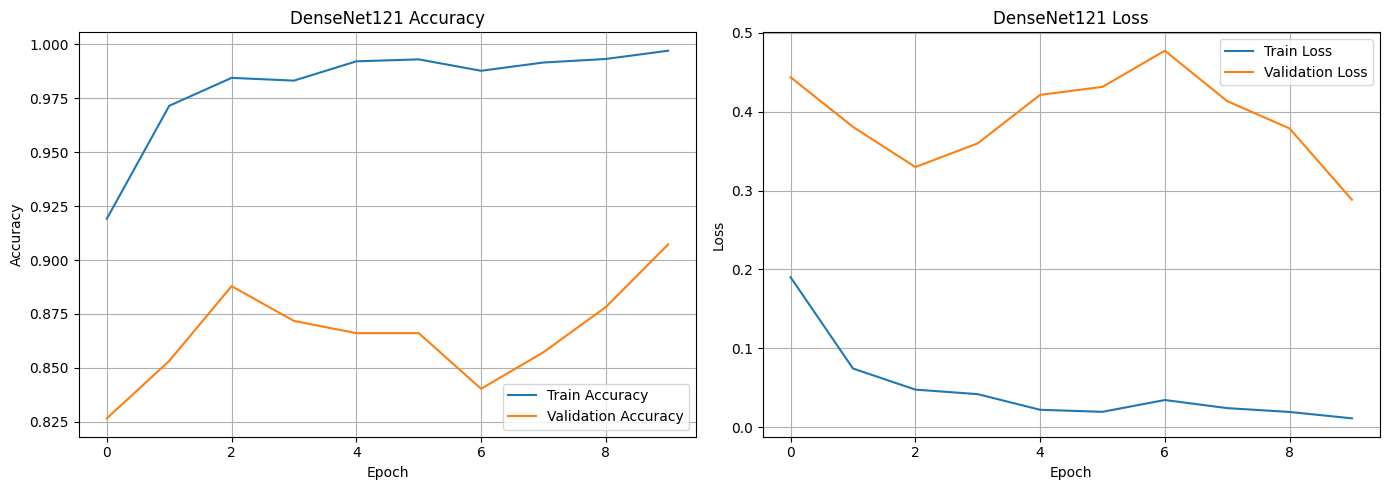

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DenseNet121 Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DenseNet121 Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "DenseNet121_Training_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
model.load_state_dict(
    torch.load("best_densenet121.pth")
)

<All keys matched successfully>

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())

        y_pred.extend(preds.cpu().numpy())

        y_prob.extend(
            probs[:,1].cpu().numpy()
        )

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.80      0.56      0.66       421
   Malignant       0.79      0.92      0.85       767

    accuracy                           0.79      1188
   macro avg       0.80      0.74      0.76      1188
weighted avg       0.80      0.79      0.78      1188



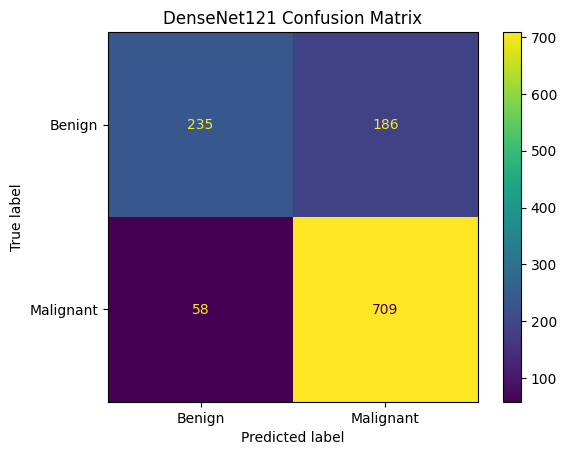

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
)

disp.plot()

plt.title("DenseNet121 Confusion Matrix")

plt.savefig(
    "DenseNet121_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

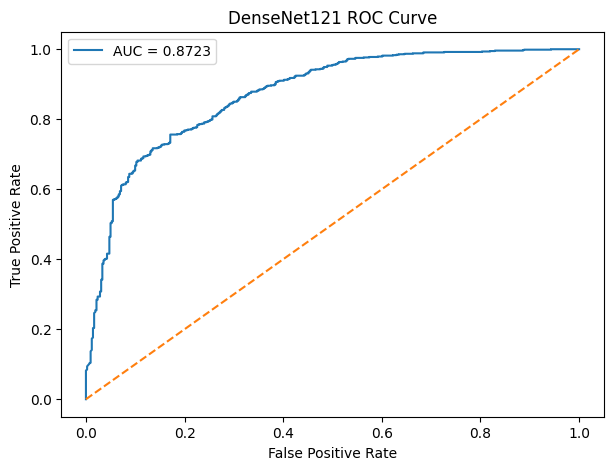

In [ ]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

auc_score = roc_auc_score(
    y_true,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("DenseNet121 ROC Curve")

plt.legend()

plt.savefig(
    "DenseNet121_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_true,y_pred))
print("Precision:", precision_score(y_true,y_pred))
print("Recall   :", recall_score(y_true,y_pred))
print("F1 Score :", f1_score(y_true,y_pred))
print("AUC      :", auc_score)

Accuracy : 0.7946127946127947
Precision: 0.7921787709497207
Recall   : 0.924380704041721
F1 Score : 0.8531889290012034
AUC      : 0.8723068871222984


# EfficientNetB0

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Parameters

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

Training Setup

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

Train Function

In [ ]:
from tqdm import tqdm

def train_efficientnet(model, epochs=10):

    best_acc = 0

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0
        train_true, train_pred = [], []

        for x, y in tqdm(train_loader):

            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            out = model(x)

            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = out.argmax(1)

            train_true.extend(y.cpu().numpy())
            train_pred.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_true, train_pred)

        # ---------------- VALIDATION ----------------
        model.eval()

        val_loss = 0
        val_true, val_pred = [], []

        with torch.no_grad():

            for x, y in val_loader:

                x, y = x.to(device), y.to(device)

                out = model(x)

                loss = criterion(out, y)

                val_loss += loss.item()

                preds = out.argmax(1)

                val_true.extend(y.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_true, val_pred)

        # ---------------- Save History ----------------
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc:.4f}, "
            f"Val Acc={val_acc:.4f}"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_efficientnet.pth")

    print("Best Val Accuracy:", best_acc)

In [ ]:
train_efficientnet(model)

100%|██████████| 172/172 [01:45<00:00,  1.63it/s]


Epoch 1: Train Acc=0.9059, Val Acc=0.7935


100%|██████████| 172/172 [01:45<00:00,  1.62it/s]


Epoch 2: Train Acc=0.9710, Val Acc=0.7944


100%|██████████| 172/172 [01:46<00:00,  1.61it/s]


...

Epoch 8: Train Acc=0.9934, Val Acc=0.8379


100%|██████████| 172/172 [01:46<00:00,  1.62it/s]


Epoch 9: Train Acc=0.9951, Val Acc=0.7992


100%|██████████| 172/172 [01:46<00:00,  1.62it/s]


Epoch 10: Train Acc=0.9932, Val Acc=0.8863
Best Val Accuracy: 0.8862903225806451


Combined Accuracy + Loss Graph

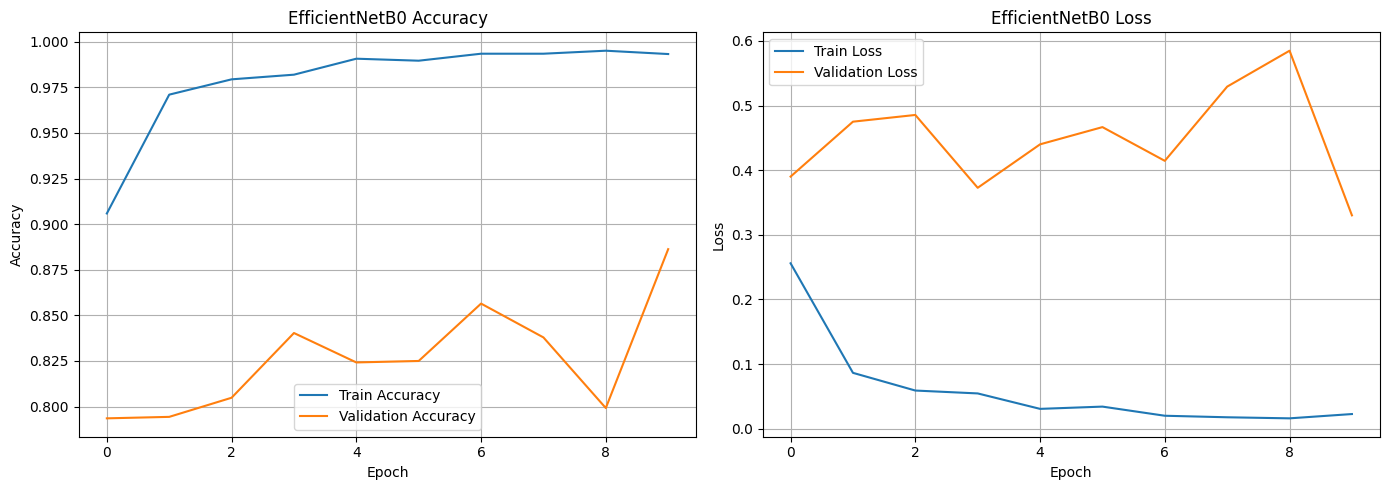

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# ---------------- Accuracy ----------------
plt.subplot(1,2,1)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.legend()
plt.grid(True)

# ---------------- Loss ----------------
plt.subplot(1,2,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "EfficientNetB0_Training_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

Load Best Model

In [ ]:
model.load_state_dict(
    torch.load("best_efficientnet.pth")
)

<All keys matched successfully>

Test Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

y_true, y_pred, y_prob = [], [], []

model.eval()

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        out = model(x)

        prob = torch.softmax(out, dim=1)[:,1]

        pred = out.argmax(1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.78      0.66      0.71       421
   Malignant       0.83      0.90      0.86       767

    accuracy                           0.81      1188
   macro avg       0.80      0.78      0.78      1188
weighted avg       0.81      0.81      0.81      1188



Confusion Matrix

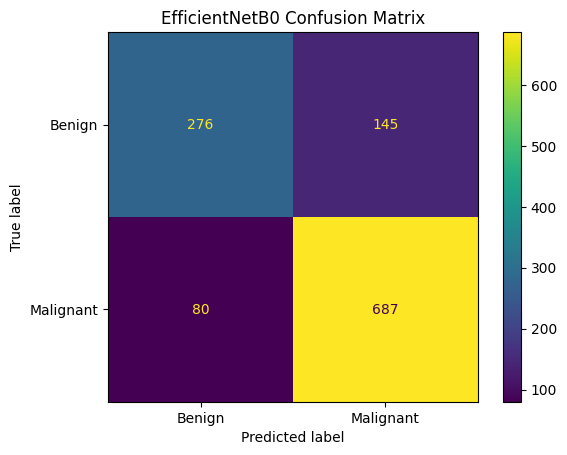

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("EfficientNetB0 Confusion Matrix")

plt.savefig(
    "EfficientNetB0_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC Curve

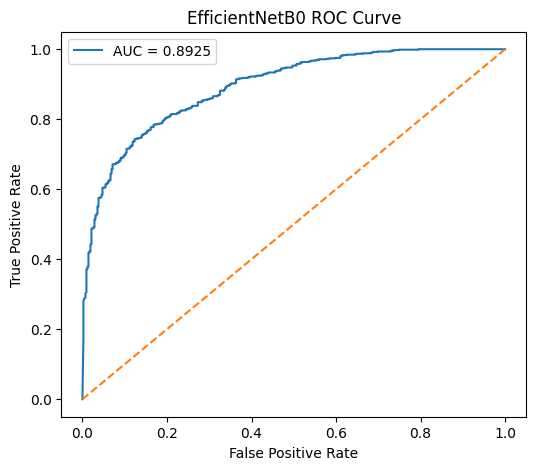

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("EfficientNetB0 ROC Curve")

plt.legend()

plt.savefig(
    "EfficientNetB0_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_true,y_pred))
print("Precision:", precision_score(y_true,y_pred))
print("Recall   :", recall_score(y_true,y_pred))
print("F1 Score :", f1_score(y_true,y_pred))
print("AUC      :", auc_score)

Accuracy : 0.8005050505050505
Precision: 0.8162291169451074
Recall   : 0.8917861799217731
F1 Score : 0.8523364485981308
AUC      : 0.8624805284493677


# ResNet50

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Parameters

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

Training History Containers

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [ ]:
from tqdm import tqdm

def train_resnet(model, epochs=10):

    best_acc = 0

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0
        train_true, train_pred = [], []

        for x, y in tqdm(train_loader):

            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            out = model(x)

            loss = criterion(out, y)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = out.argmax(1)

            train_true.extend(y.cpu().numpy())
            train_pred.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_true, train_pred)

        # ---------------- VALIDATION ----------------
        model.eval()

        val_loss = 0
        val_true, val_pred = [], []

        with torch.no_grad():

            for x, y in val_loader:

                x, y = x.to(device), y.to(device)

                out = model(x)

                loss = criterion(out, y)

                val_loss += loss.item()

                preds = out.argmax(1)

                val_true.extend(y.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_true, val_pred)

        # save history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc:.4f}, "
            f"Val Acc={val_acc:.4f}"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_resnet50.pth")

    print("Best Val Accuracy:", best_acc)

In [ ]:
train_resnet(model)

100%|██████████| 172/172 [02:14<00:00,  1.28it/s]


Epoch 1: Train Acc=0.8911, Val Acc=0.8839


100%|██████████| 172/172 [02:14<00:00,  1.28it/s]


Epoch 2: Train Acc=0.9706, Val Acc=0.8653


100%|██████████| 172/172 [02:13<00:00,  1.29it/s]


...

Epoch 18: Train Acc=0.9958, Val Acc=0.8492


100%|██████████| 172/172 [02:13<00:00,  1.29it/s]


Epoch 19: Train Acc=0.9964, Val Acc=0.8492


100%|██████████| 172/172 [02:13<00:00,  1.29it/s]


Epoch 20: Train Acc=0.9976, Val Acc=0.8177
Best Val Accuracy: 0.907258064516129


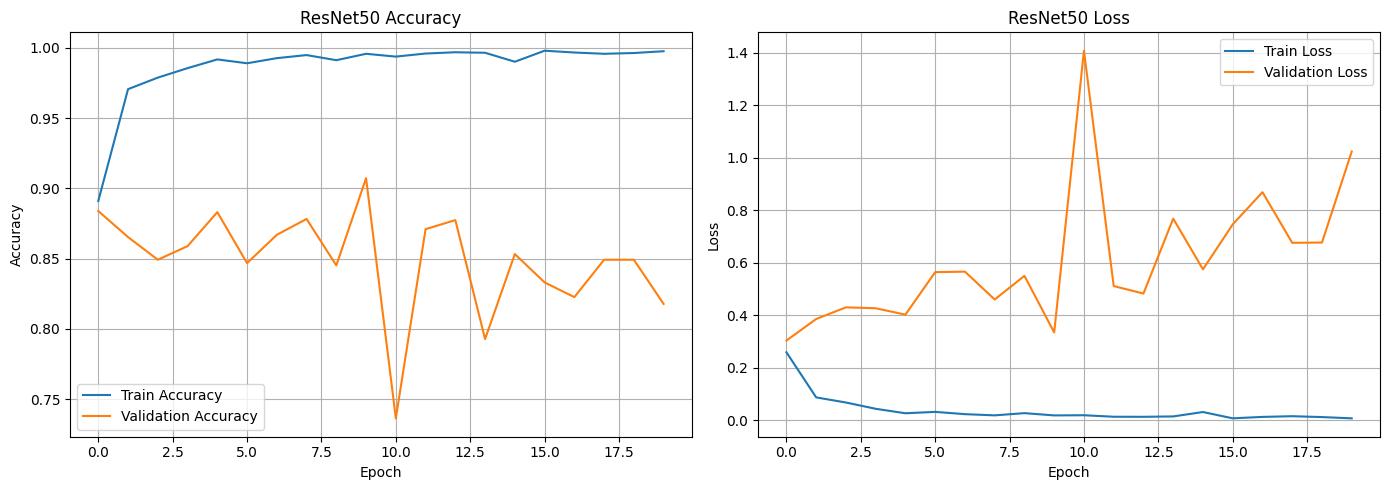

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "ResNet50_Training_Curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
model.load_state_dict(
    torch.load("best_resnet50.pth")
)

<All keys matched successfully>

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

y_true, y_pred, y_prob = [], [], []

model.eval()

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        out = model(x)

        prob = torch.softmax(out, dim=1)[:,1]

        pred = out.argmax(1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.70      0.67      0.68       421
   Malignant       0.82      0.84      0.83       767

    accuracy                           0.78      1188
   macro avg       0.76      0.76      0.76      1188
weighted avg       0.78      0.78      0.78      1188



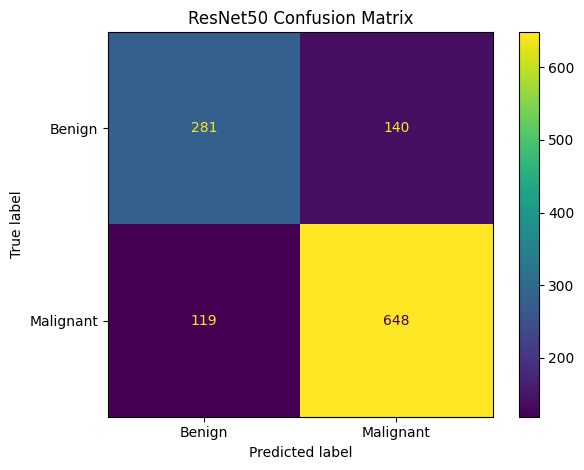

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("ResNet50 Confusion Matrix")

plt.tight_layout()
plt.savefig(
    "ResNet50_Confusion Matrixs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

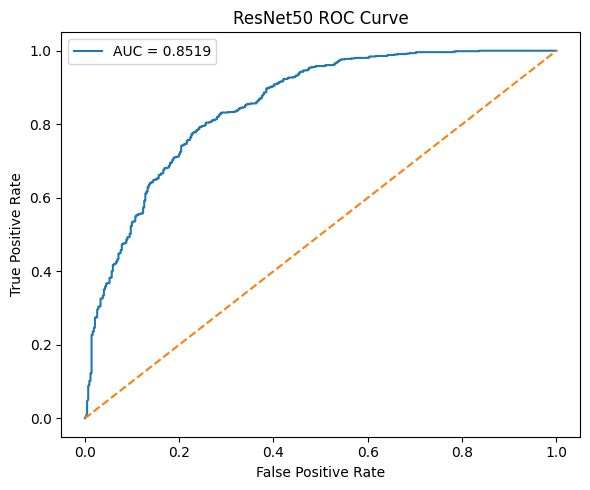

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ResNet50 ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    "ResNet50_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_true,y_pred))
print("Precision:", precision_score(y_true,y_pred))
print("Recall   :", recall_score(y_true,y_pred))
print("F1 Score :", f1_score(y_true,y_pred))
print("AUC      :", auc_score)

Accuracy : 0.8005050505050505
Precision: 0.8162291169451074
Recall   : 0.8917861799217731
F1 Score : 0.8523364485981308
AUC      : 0.8624805284493677


# Vision Transformer (ViT-B/16)

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.vit_b_16(
    weights=models.ViT_B_16_Weights.DEFAULT
)

model.heads.head = nn.Linear(
    model.heads.head.in_features,
    2
)

model = model.to(device)

print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Parameters

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Training History

In [ ]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

Training Function

In [ ]:
from tqdm import tqdm

def train_vit(model, epochs=20):

    best_acc = 0

    for epoch in range(epochs):


        # ---------------- TRAIN ----------------

        model.train()

        running_loss = 0

        train_true = []
        train_pred = []

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(1)

            train_true.extend(
                labels.cpu().numpy()
            )

            train_pred.extend(
                preds.cpu().numpy()
            )

        train_loss = running_loss / len(train_loader)

        train_acc = accuracy_score(
            train_true,
            train_pred
        )

        # ---------------- VALIDATION ----------------

        model.eval()

        val_running_loss = 0

        val_true = []
        val_pred = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_running_loss += loss.item()

                preds = outputs.argmax(1)

                val_true.extend(
                    labels.cpu().numpy()
                )

                val_pred.extend(
                    preds.cpu().numpy()
                )

        val_loss = val_running_loss / len(val_loader)

        val_acc = accuracy_score(
            val_true,
            val_pred
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc:.4f} "
            f"Val Acc={val_acc:.4f}"
        )

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_vit.pth"
            )

    print(
        "Best Validation Accuracy:",
        best_acc
    )

Train ViT

In [ ]:
train_vit(
    model,
    epochs=10
)

100%|██████████| 172/172 [04:39<00:00,  1.63s/it]


Epoch 1: Train Acc=0.8643 Val Acc=0.8960


100%|██████████| 172/172 [04:38<00:00,  1.62s/it]


Epoch 2: Train Acc=0.9562 Val Acc=0.7879


100%|██████████| 172/172 [04:37<00:00,  1.61s/it]


...

Epoch 8: Train Acc=0.9838 Val Acc=0.8919


100%|██████████| 172/172 [04:37<00:00,  1.61s/it]


Epoch 9: Train Acc=0.9876 Val Acc=0.8266


100%|██████████| 172/172 [04:46<00:00,  1.67s/it]


Epoch 10: Train Acc=0.9869 Val Acc=0.8435
Best Validation Accuracy: 0.9048387096774193


Combined Accuracy + Loss Graph

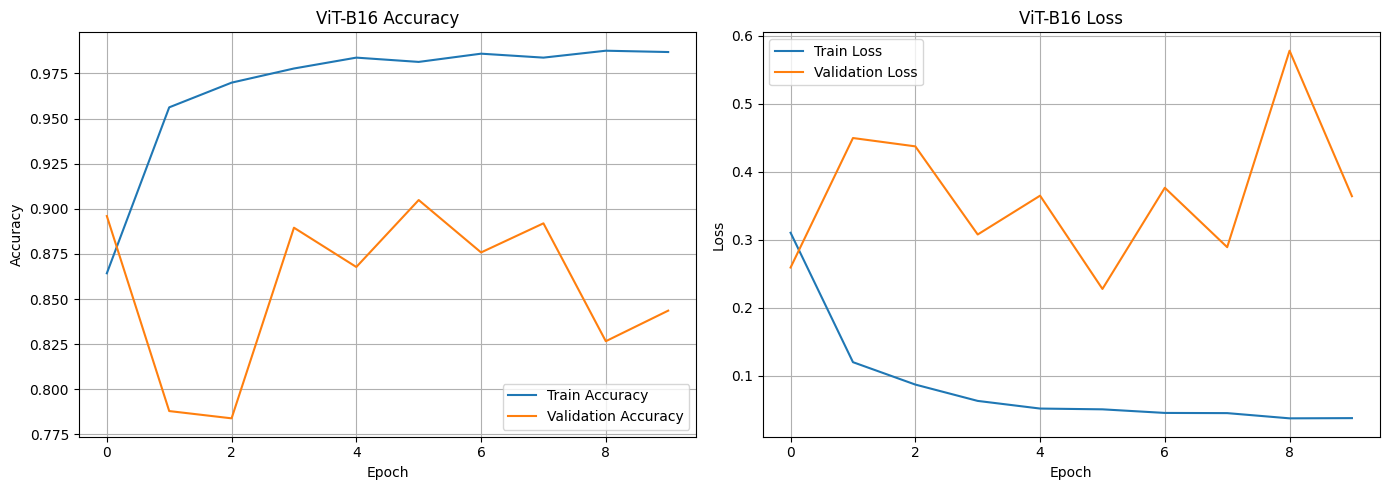

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# ---------------- Accuracy ----------------

plt.subplot(1,2,1)

plt.plot(
    train_accs,
    label='Train Accuracy'
)

plt.plot(
    val_accs,
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "ViT-B16 Accuracy"
)

plt.legend()

plt.grid(True)

# ---------------- Loss ----------------

plt.subplot(1,2,2)

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ViT-B16 Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "ViT-B16_Training_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Load Best Model

In [ ]:
model.load_state_dict(
    torch.load(
        "best_vit.pth"
    )
)

<All keys matched successfully>

Test Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_prob.extend(
            probs[:,1].cpu().numpy()
        )

Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.73      0.47      0.57       421
   Malignant       0.76      0.90      0.82       767

    accuracy                           0.75      1188
   macro avg       0.74      0.69      0.70      1188
weighted avg       0.75      0.75      0.73      1188



Confusion Matrix

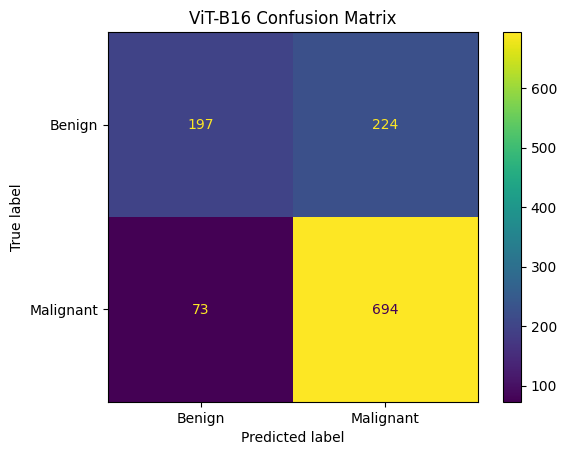

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
)

disp.plot()

plt.title(
    "ViT-B16 Confusion Matrix"
)

plt.savefig(
    "ViT-B16_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC Curve

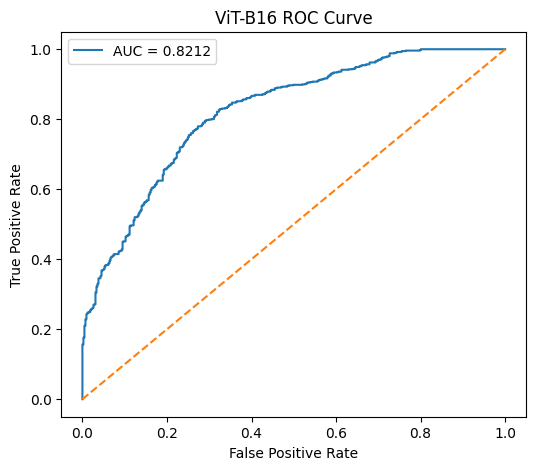

In [ ]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

auc_score = roc_auc_score(
    y_true,
    y_prob
)

plt.figure(
    figsize=(6,5)
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ViT-B16 ROC Curve"
)

plt.legend()

plt.savefig(
    "ViT-B16_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Final Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_true,
        y_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_true,
        y_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        y_pred
    )
)

print(
    "F1 Score:",
    f1_score(
        y_true,
        y_pred
    )
)

print(
    "AUC:",
    auc_score
)

Accuracy: 0.75
Precision: 0.7559912854030502
Recall: 0.9048239895697523
F1 Score: 0.8237388724035608
AUC: 0.8212457456790965


# Xception

Install & Import

In [ ]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [ ]:
import timm
import torch
import torch.nn as nn

Model Code

In [ ]:
model = timm.create_model(
    'xception',
    pretrained=True,
    num_classes=2
)

model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Xception(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU(inplace=True)
  (block1): Block(
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (rep): Sequential(
      (0): SeparableConv2d(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)


Parameters

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Training History

In [ ]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

Training Function

In [ ]:
from tqdm import tqdm

def train_xception(model, epochs=10):

    best_acc = 0

    for epoch in range(epochs):

        # TRAIN
        model.train()

        running_loss = 0

        train_true = []
        train_pred = []

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(1)

            train_true.extend(labels.cpu().numpy())
            train_pred.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader)

        train_acc = accuracy_score(
            train_true,
            train_pred
        )

        # ---------------- VALIDATION ----------------
        model.eval()

        val_running_loss = 0

        val_true = []
        val_pred = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                preds = outputs.argmax(1)

                val_true.extend(labels.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)

        val_acc = accuracy_score(
            val_true,
            val_pred
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc:.4f} "
            f"Val Acc={val_acc:.4f}"
        )

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_xception.pth"
            )

    print(
        "Best Validation Accuracy:",
        best_acc
    )

Train Model

In [ ]:
train_xception(
    model,
    epochs=10
)

100%|██████████| 172/172 [02:55<00:00,  1.02s/it]


Epoch 1: Train Acc=0.9046 Val Acc=0.8766


100%|██████████| 172/172 [03:00<00:00,  1.05s/it]


Epoch 2: Train Acc=0.9772 Val Acc=0.8935


100%|██████████| 172/172 [02:59<00:00,  1.05s/it]


...

Epoch 8: Train Acc=0.9938 Val Acc=0.8710


100%|██████████| 172/172 [02:56<00:00,  1.03s/it]


Epoch 9: Train Acc=0.9982 Val Acc=0.9145


100%|██████████| 172/172 [02:53<00:00,  1.01s/it]


Epoch 10: Train Acc=0.9987 Val Acc=0.8468
Best Validation Accuracy: 0.9145161290322581


Accuracy + Loss Graph

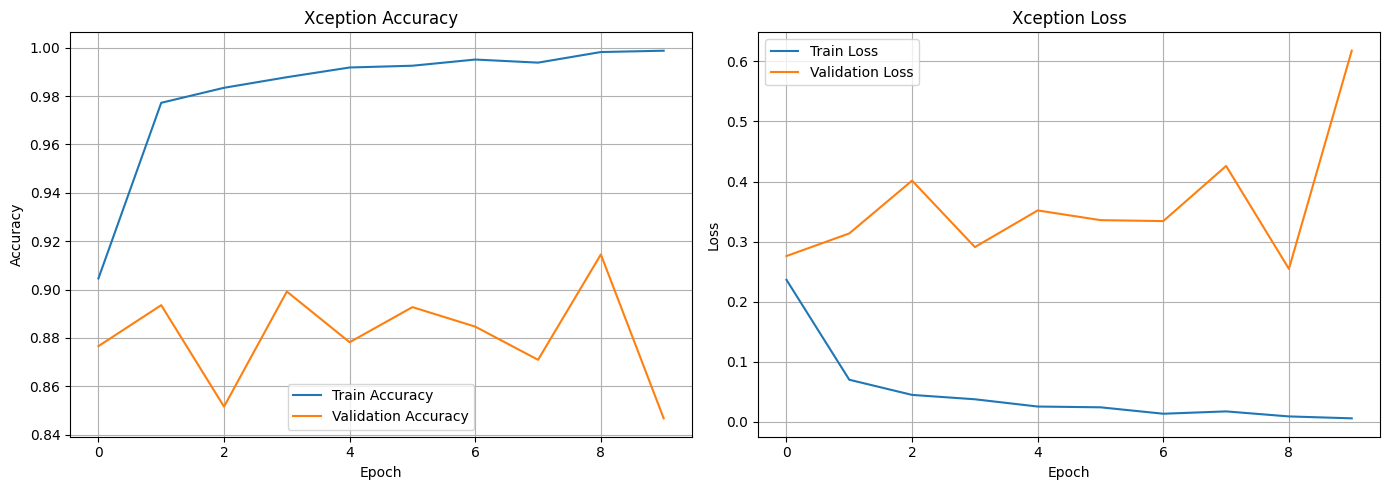

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# ---------------- Accuracy ----------------
plt.subplot(1,2,1)

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Xception Accuracy"
)

plt.legend()
plt.grid(True)

# ---------------- Loss ----------------
plt.subplot(1,2,2)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Xception Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Xception_Training_Curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Load Best Model

In [ ]:
model.load_state_dict(
    torch.load(
        "best_xception.pth"
    )
)

<All keys matched successfully>

Test Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_prob.extend(
            probs[:,1].cpu().numpy()
        )

Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Confusion Matrix

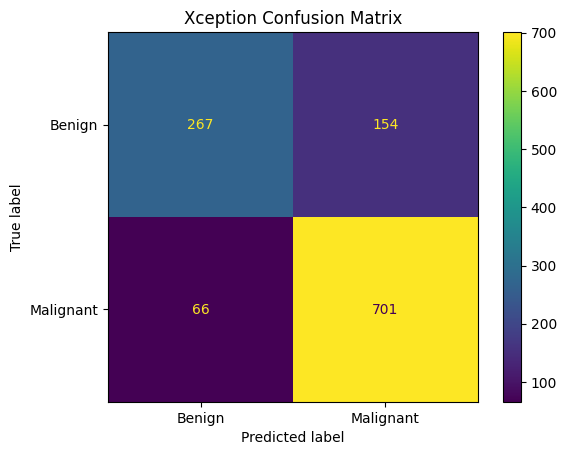

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
)

disp.plot()

plt.title(
    "Xception Confusion Matrix"
)

plt.savefig(
    "Xception_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC Curve

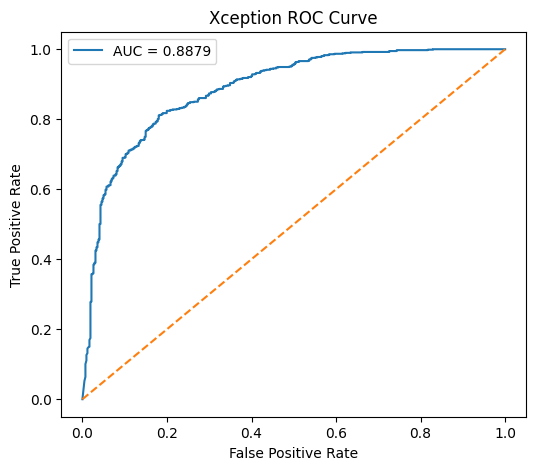

In [ ]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

auc_score = roc_auc_score(
    y_true,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Xception ROC Curve"
)

plt.legend()

plt.savefig(
    "Xception_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Final Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("AUC      :", auc_score)

Accuracy : 0.8148148148148148
Precision: 0.8198830409356725
Recall   : 0.9139504563233377
F1 Score : 0.8643649815043156
AUC      : 0.887918193163976


# MobileNetV3

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.DEFAULT
)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    2
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 143MB/s] 


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

Parameters

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Training History

In [ ]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

Training Function

In [ ]:
from tqdm import tqdm

def train_mobilenet(model, epochs=10):

    best_acc = 0

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0

        train_true = []
        train_pred = []

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(1)

            train_true.extend(labels.cpu().numpy())
            train_pred.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader)

        train_acc = accuracy_score(
            train_true,
            train_pred
        )

        # ---------------- VALIDATION ----------------
        model.eval()

        val_running_loss = 0

        val_true = []
        val_pred = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                preds = outputs.argmax(1)

                val_true.extend(labels.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)

        val_acc = accuracy_score(
            val_true,
            val_pred
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc:.4f} "
            f"Val Acc={val_acc:.4f}"
        )

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_mobilenetv3.pth"
            )

    print(
        "Best Validation Accuracy:",
        best_acc
    )

Train Model

In [ ]:
train_mobilenet(
    model,
    epochs=10
)

100%|██████████| 172/172 [01:32<00:00,  1.85it/s]


Epoch 1: Train Acc=0.8993 Val Acc=0.9065


100%|██████████| 172/172 [01:33<00:00,  1.84it/s]


Epoch 2: Train Acc=0.9761 Val Acc=0.9105


100%|██████████| 172/172 [01:32<00:00,  1.85it/s]


...

Epoch 8: Train Acc=0.9916 Val Acc=0.8653


100%|██████████| 172/172 [01:39<00:00,  1.72it/s]


Epoch 9: Train Acc=0.9973 Val Acc=0.8661


100%|██████████| 172/172 [01:36<00:00,  1.78it/s]


Epoch 10: Train Acc=0.9976 Val Acc=0.8887
Best Validation Accuracy: 0.9169354838709678


Combined Accuracy + Loss Graph

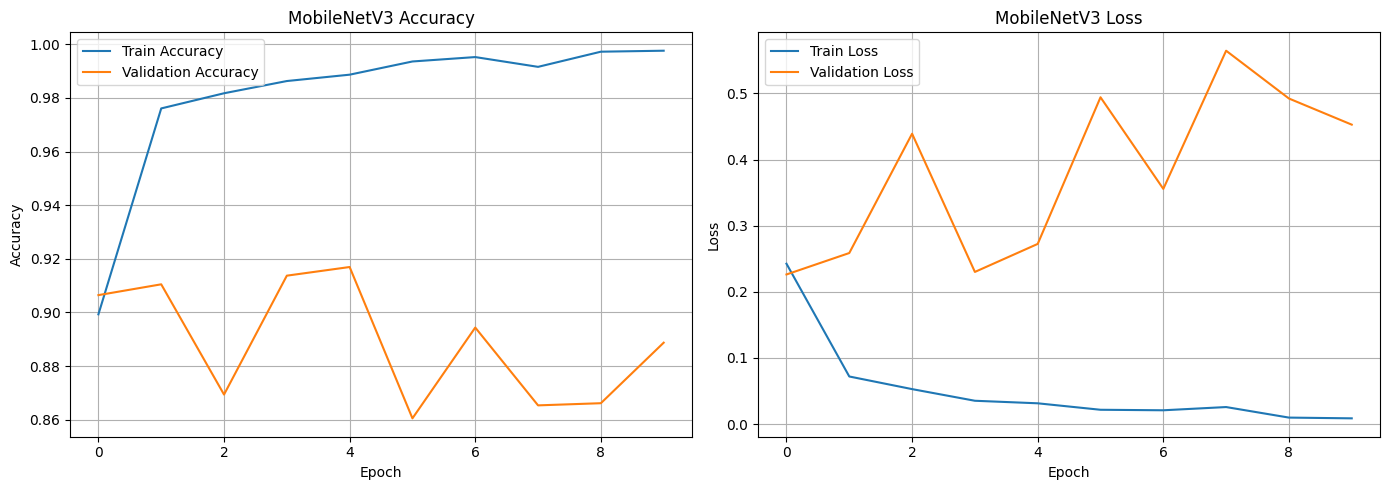

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# ---------------- Accuracy ----------------
plt.subplot(1,2,1)

plt.plot(
    train_accs,
    label='Train Accuracy'
)

plt.plot(
    val_accs,
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV3 Accuracy"
)

plt.legend()
plt.grid(True)

# ---------------- Loss ----------------
plt.subplot(1,2,2)

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MobileNetV3 Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "MobileNetV3_Training_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Load Best Model

In [ ]:
model.load_state_dict(
    torch.load(
        "best_mobilenetv3.pth"
    )
)

<All keys matched successfully>

Test Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_prob.extend(
            probs[:,1].cpu().numpy()
        )

Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Confusion Matrix

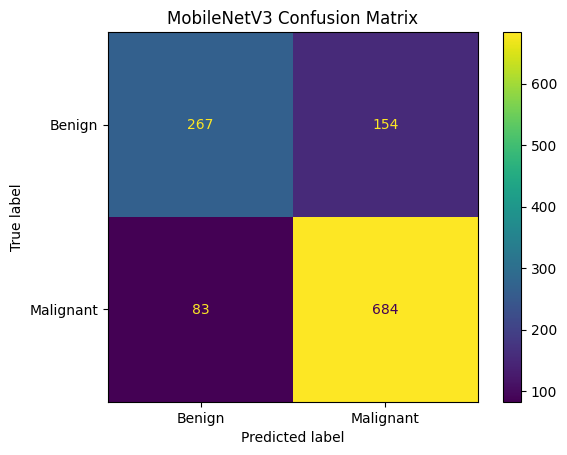

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
)

disp.plot()

plt.title(
    "MobileNetV3 Confusion Matrix"
)

plt.savefig(
    "MobileNetV3_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC Curve

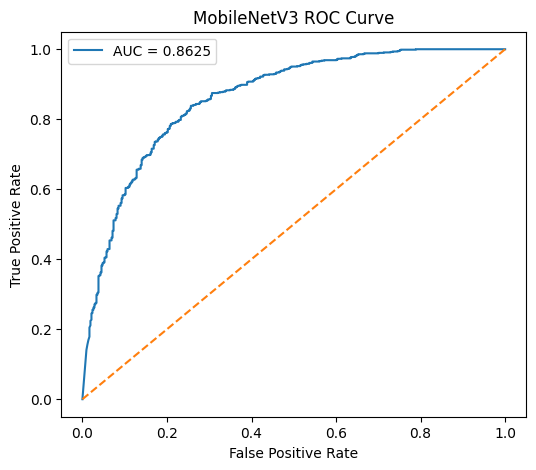

In [ ]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

auc_score = roc_auc_score(
    y_true,
    y_prob
)

plt.figure(
    figsize=(6,5)
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "MobileNetV3 ROC Curve"
)

plt.legend()

plt.savefig(
    "MobileNetV3_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Final Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_true,
        y_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_true,
        y_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        y_pred
    )
)

print(
    "F1 Score:",
    f1_score(
        y_true,
        y_pred
    )
)

print(
    "AUC:",
    auc_score
)

Accuracy: 0.8005050505050505
Precision: 0.8162291169451074
Recall: 0.8917861799217731
F1 Score: 0.8523364485981308
AUC: 0.8624805284493677


# Grad Cam ++

In [ ]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
model.load_state_dict(torch.load("best_mobilenetv3.pth"))
model.to(device)
model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [ ]:
target_layers = [model.features[-1]]

In [ ]:
def prepare_image(img_tensor):

    img = img_tensor.permute(1, 2, 0).cpu().numpy()

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    return img

images, labels = next(iter(test_loader))

image_tensor = images[0].unsqueeze(0).to(device)
label = labels[0].item()

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

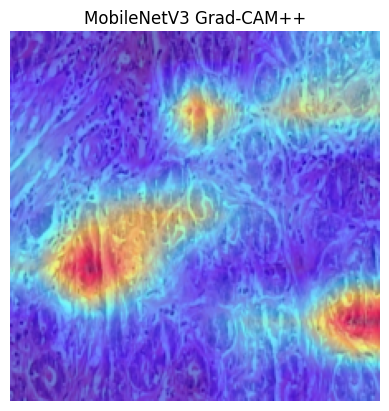

In [ ]:
cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

model = model.to(device)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


target_layers = [model.features[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

targets = [ClassifierOutputTarget(labels[0].item())]

grayscale_cam = cam(
    input_tensor=img,
    targets=targets
)[0]

import matplotlib.pyplot as plt

def prepare_image(img_tensor):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

image = prepare_image(images[0])

visualization = show_cam_on_image(
    image,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(visualization)
plt.axis("off")
plt.title("MobileNetV3 Grad-CAM++")
plt.savefig(
    "MobileNetV3_Grad_CAM_Plus.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Final Comparison Table

            Model  Accuracy  Precision  Recall  F1-score     AUC
0        Xception    0.8148     0.8199  0.9140    0.8644  0.8879
1     DenseNet121    0.7946     0.7922  0.9244    0.8532  0.8723
2     MobileNetV3    0.8005     0.8162  0.8918    0.8523  0.8625
3        ResNet50    0.8005     0.8162  0.8918    0.8523  0.8625
4  EfficientNetB0    0.8005     0.8162  0.8918    0.8523  0.8625
5        ViT-B/16    0.7500     0.7560  0.9048    0.8237  0.8212


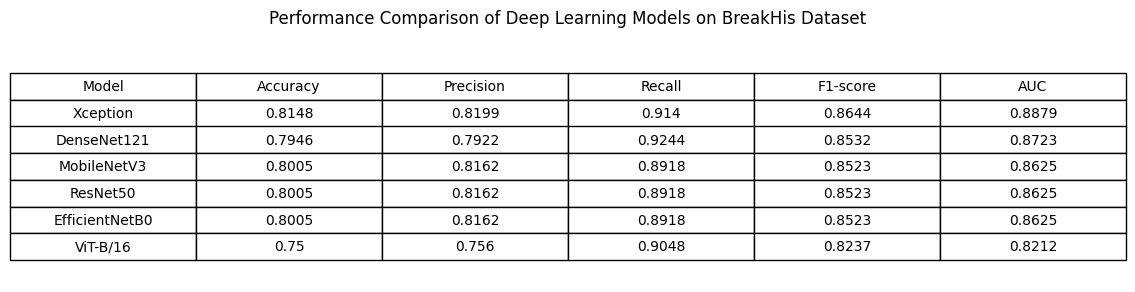

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Final Results ----------------
results = {
    "Model": [
        "Xception",
        "DenseNet121",
        "MobileNetV3",
        "ResNet50",
        "EfficientNetB0",
        "ViT-B/16"
    ],
    "Accuracy": [0.8148, 0.7946, 0.8005, 0.8005, 0.8005, 0.7500],
    "Precision": [0.8199, 0.7922, 0.8162, 0.8162, 0.8162, 0.7560],
    "Recall": [0.9140, 0.9244, 0.8918, 0.8918, 0.8918, 0.9048],
    "F1-score": [0.8644, 0.8532, 0.8523, 0.8523, 0.8523, 0.8237],
    "AUC": [0.8879, 0.8723, 0.8625, 0.8625, 0.8625, 0.8212]
}

df = pd.DataFrame(results)

# ---------------- Sort by F1-score (optional) ----------------
df = df.sort_values("F1-score", ascending=False)

print(df)

# ---------------- Create Table Figure ----------------
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table = ax.table(
    cellText=df.round(4).values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.title("Performance Comparison of Deep Learning Models on BreakHis Dataset",
          fontsize=12,
          pad=20)

plt.savefig(
    "Model_Comparison_Table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()